In [5]:
from importlib.resources import files
from neuromodes.io import fetch_surf
from neuromodes import EigenSolver
from neuromodes.parc import make_pangcellation_maskfaces
from neuromodes.mesh import unmask_data
import numpy as np
from nsbutils.plotting import plot_surf
import matplotlib.pyplot as plt

In [2]:
surf, medmask = fetch_surf()

In [3]:
solver = EigenSolver(surf, mask=medmask).solve(2)

In [4]:
pangcellation = make_pangcellation_maskfaces(solver.geometry, 10, seed=0)

c:\Users\ipop0003\neuromodes\.venv\Lib\site-packages\numpy\_core\numeric.py:386: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [8]:
print(pangcellation.shape)

# map to vertices (very dodgy)
pangcellation_v = solver.geometry.map_tfunc_to_vfunc(pangcellation)
print(pangcellation_v.shape)

(59147,)
(29696,)


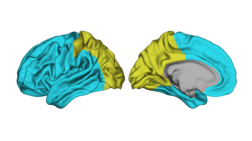

In [ ]:
# this doesn't even work lol
data = unmask_data(pangcellation_v, medmask)
surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
plot_surf(surfpath, data, cmap='tab10')

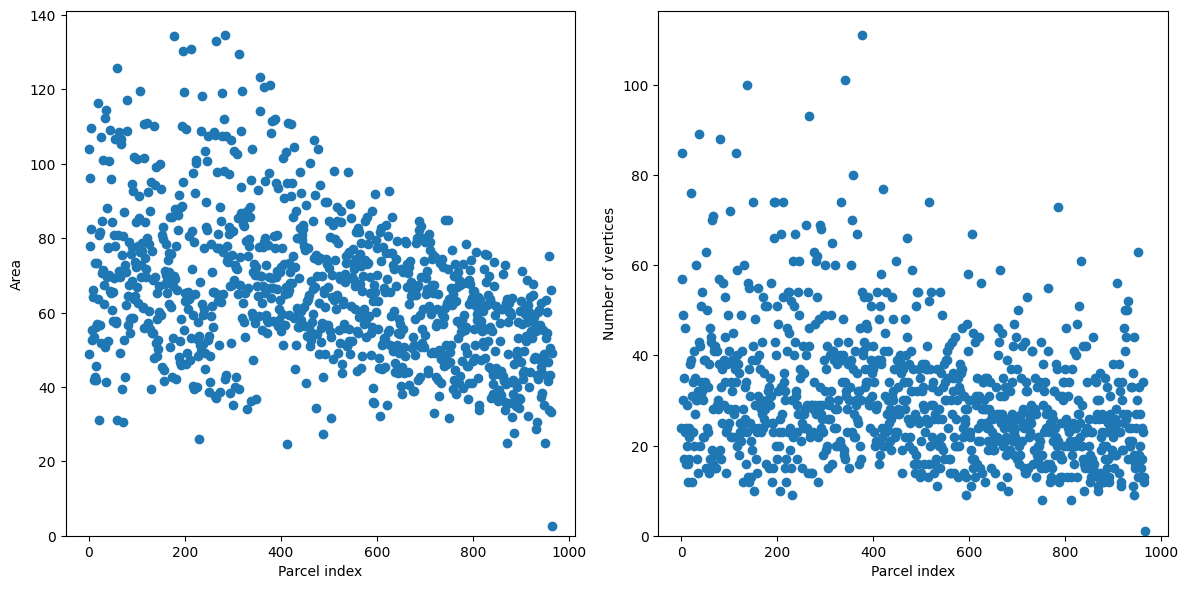

In [48]:
# plot area per parcel
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

parcel_areas = [solver.mass[pangcellation == i].sum() for i in np.unique(pangcellation)]
axs[0].plot(parcel_areas, 'o')
axs[0].set_xlabel('Parcel index')
axs[0].set_ylabel('Area')
axs[0].set_ylim(ymin=0)


# now plot number of vertices per parcel
parcel_sizes = [np.sum(pangcellation == i) for i in np.unique(pangcellation)]
axs[1].plot(parcel_sizes, 'o')
axs[1].set_xlabel('Parcel index')
axs[1].set_ylabel('Number of vertices')
axs[1].set_ylim(ymin=0)
plt.tight_layout()
plt.show()

Above works okay, but a 2-vertex parcel emerges after 966 cuts (see farthest right dot above). Since
the sparse solver can only solve for the first k < n_verts modes, we can't obtain the 967th parcel.

A potential workaround could be to demean (or project?) the initialisation vector v0, meaning that
k=1 will return mode 2.

Another workaround is to try solving on disconnected components.

Also, this whole maskmat method might be bunk.

Also, equal area paMGcellation may postpone this problem many parcels.